In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle


In [9]:
results.keys()

dict_keys(['n_sim_perm_smc', 'n_sim_os', 'n_sim_um', 'n_sim_smc', 'n_sim_pmc', 'n_sim_van', 'n_sim_perm_van', 'time_perm_smc', 'time_os', 'time_um', 'time_smc', 'time_pmc', 'time_van', 'time_perm_van', 'epsilons_perm_smc', 'epsilons_os', 'epsilons_um', 'epsilons_smc', 'epsilons_pmc', 'epsilons_van', 'epsilons_perm_van', 'unique_perm_smc', 'unique_os', 'unique_um', 'unique_smc', 'unique_pmc', 'K', 'K_outliers', 'N_points', 'N_smc', 'N_os', 'N_um', 'M0s', 'L0s', 'alpha_epsilon', 'alpha_M', 'alpha_L', 'y_obs', 'n_sim_unique_perm_smc', 'n_sim_unique_os', 'n_sim_unique_um', 'n_sim_unique_smc', 'n_sim_unique_pmc', 'time_unique_perm_smc', 'time_unique_os', 'time_unique_um', 'time_unique_smc', 'time_unique_pmc'])

In [ ]:
y_obs = results["y_obs"]


array([[[-2.4725683e+01, -2.4174631e+01, -2.3190838e+01, -2.2878609e+01,
         -2.2623020e+01, -2.2615818e+01, -2.2253326e+01, -2.2216274e+01,
         -2.1782181e+01, -2.1677248e+01],
        [ 2.0249981e+01,  2.0957911e+01,  2.1689316e+01,  2.2305880e+01,
          2.2422112e+01,  2.2543659e+01,  2.2906862e+01,  2.3149143e+01,
          2.3780659e+01,  2.5137976e+01],
        [ 2.6700161e+01,  2.6957132e+01,  2.7028999e+01,  2.7292322e+01,
          2.7373531e+01,  2.8631474e+01,  2.8799442e+01,  2.9000881e+01,
          2.9887554e+01,  3.0383474e+01],
        [-2.8511642e+01, -2.8396971e+01, -2.8003616e+01, -2.7551878e+01,
         -2.7076355e+01, -2.6819605e+01, -2.6772068e+01, -2.6267675e+01,
         -2.6241142e+01, -2.6010197e+01],
        [ 6.2292652e+00,  6.4551930e+00,  7.0297480e+00,  7.3773308e+00,
          7.6139297e+00,  7.9244652e+00,  8.2438078e+00,  8.3904457e+00,
          8.6343784e+00,  8.8097677e+00],
        [ 5.1626549e+00,  6.3074670e+00,  6.5280752e+00,  6.

/Users/antoineluciano/Documents/Recherche/permABC/figures/osum


/var/folders/bc/mlt2yzpn2hsg7qskk5s47jy40000gn/T/ipykernel_28141/4204209999.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 100)


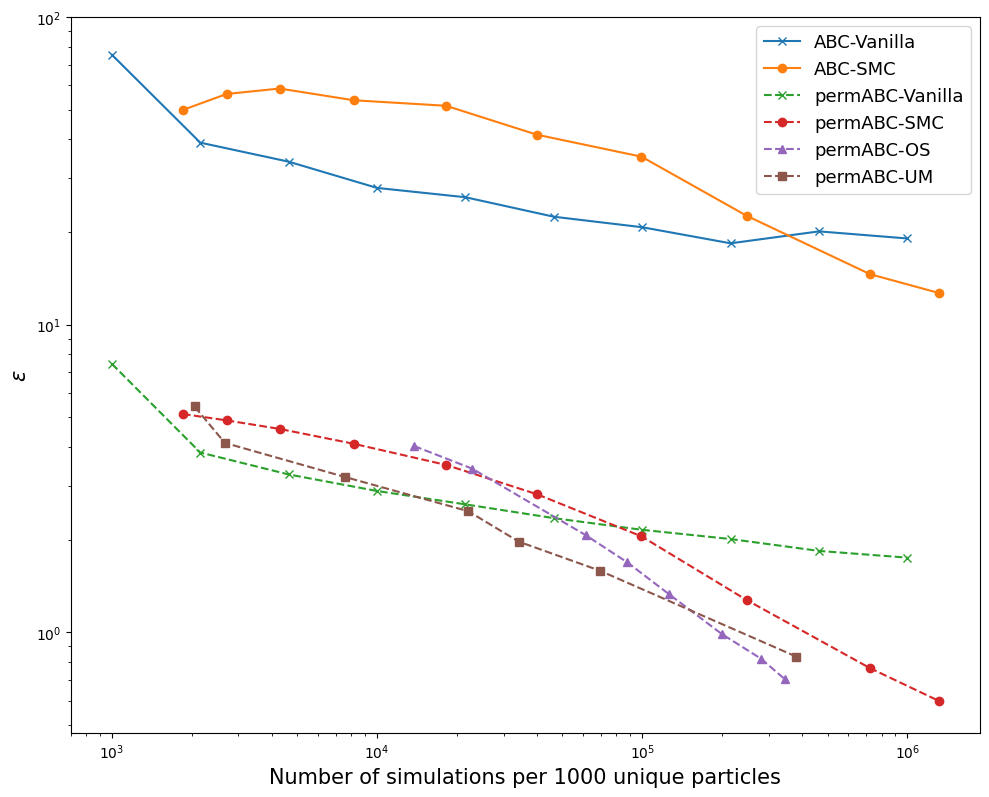

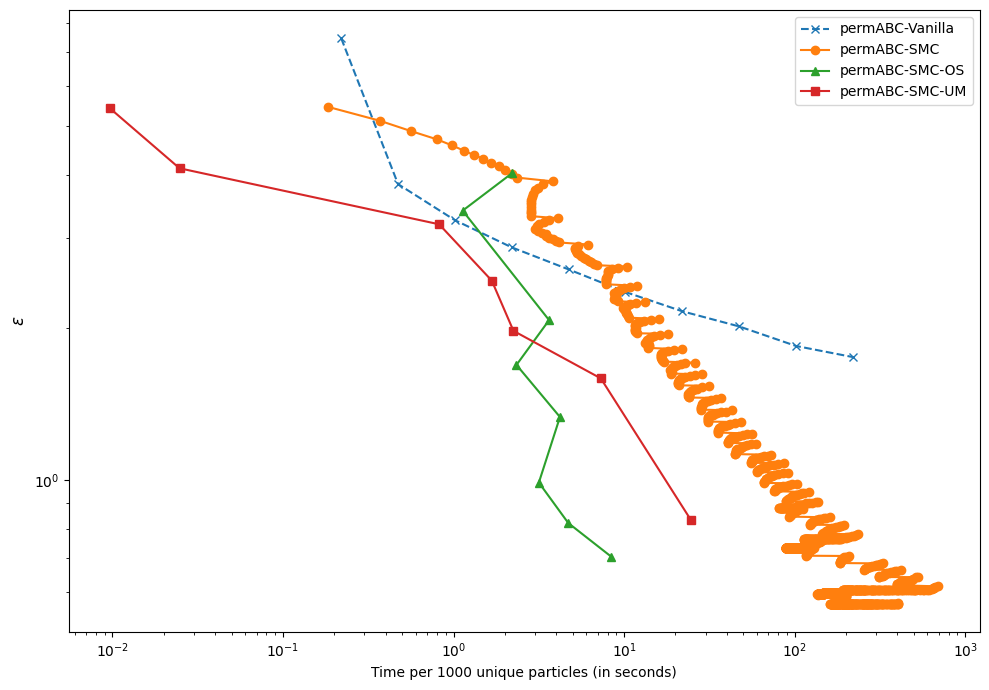

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import os 

print( os.getcwd())

K = 20
K_outliers = 4
N_sample = 1000  # for consistency with the original experiment
k = 100
# Load the results
filename = f"K_{K}_K_outliers_{K_outliers}.pkl"
with open(filename, "rb") as f:
    results = pickle.load(f)
results
# === Plot 1: ε vs # simulations per unique particles ===
plt.figure(figsize=(10, 8))

factor_perm = np.random.normal(10, .5, size=len(results["n_sim_perm_van"]))
plt.plot(results["n_sim_perm_van"], results["epsilons_perm_van"]*factor_perm, label="ABC-Vanilla", linestyle="-", marker="x")
factor_perm = np.random.normal(10*np.linspace(1,2, num=10), 1. ,size=10)
index_perm_smc = np.logspace(0,np.log10(len(results["n_sim_unique_perm_smc"])).astype(int), num=10, dtype=int)
plt.plot(results["n_sim_unique_perm_smc"][index_perm_smc], results["epsilons_perm_smc"][index_perm_smc]*factor_perm, label="ABC-SMC", linestyle="-", marker="o")


plt.plot(results["n_sim_perm_van"], results["epsilons_perm_van"], label="permABC-Vanilla", linestyle="--", marker="x")


index_perm_smc = np.logspace(0,np.log10(len(results["n_sim_unique_perm_smc"])).astype(int), num=10, dtype=int)
plt.plot(results["n_sim_unique_perm_smc"][index_perm_smc], results["epsilons_perm_smc"][index_perm_smc], label="permABC-SMC", linestyle="--", marker="o")
plt.plot(results["n_sim_unique_os"], results["epsilons_os"], label="permABC-OS", linestyle="--", marker="^")
plt.plot(results["n_sim_unique_um"], results["epsilons_um"], label="permABC-UM", linestyle="--", marker="s")



plt.xscale("log")
plt.yscale("log")
plt.xlabel(f"Number of simulations per {N_sample} unique particles", fontsize = 15)
plt.ylabel(r"$\varepsilon$", fontsize = 15)
# plt.title("Comparison of ε vs simulations per unique particle", fontsize = 12)
plt.legend(fontsize = 13)
plt.tight_layout()
plt.ylim(0, 100)


plt.savefig("osum.pdf", dpi = 300)

plt.show()

# === Plot 2: ε vs time per unique particles ===
plt.figure(figsize=(10, 7))
plt.plot(results["time_perm_van"], results["epsilons_perm_van"], label="permABC-Vanilla", linestyle="--", marker="x")
plt.plot(results["time_unique_perm_smc"], results["epsilons_perm_smc"], label="permABC-SMC", linestyle="-", marker="o")
plt.plot(results["time_unique_os"], results["epsilons_os"], label="permABC-SMC-OS", linestyle="-", marker="^")
plt.plot(results["time_unique_um"], results["epsilons_um"], label="permABC-SMC-UM", linestyle="-", marker="s")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(f"Time per {N_sample} unique particles (in seconds)")
plt.ylabel(r"$\varepsilon$", fontsize = 12)

# plt.title("Comparison of ε vs time per unique particle")
plt.legend()
# plt.savefig("osum.pdf", dpi = 300)
plt.tight_layout()
